# tap.fuzz~ — the dirt, measured

A two-stage, tone-stacked distortion (`taptools/fuzz.h`): the harder, more scooped school that
sits beside `tap.overdrive~`'s feedback soft-clipper rather than replacing it.

The method is not invented here. It is the **simplified cascade** of Yeh, Abel & Smith,
*"Simplified, Physically-Informed Models of Distortion and Overdrive Guitar Effects Pedals"*
(Proc. DAFx-07): conditioning filter → memoryless nonlinearity → equalization filter, twice.
That paper is also where the justification comes from — the diode limiter is really a lowpass
whose pole moves with voltage, its exact ODE is expensive, and approximating it as a static
curve between fixed filters is defended there and measured against real pedals. It is a
recreation of a *class* of circuit; no component value here is claimed as measured from any
unit.

Two of the sections below exist because the first implementation was wrong and measurement
caught it: the gain staging (§2) and the oversampling filter order (§5).

Every trace drives the **shipping C++** through `tools/capi` via ctypes.

Sections: **1** the curve · **2** gain staging · **3** the even harmonics · **4** the tone stack
· **5** aliasing, and a house pattern that did not survive

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def pedal(**params):
    base = dict(smooth_ms=0, bass=0.0, treble=0.0, contrast=0.0, asymmetry=0.0, level_db=0.0)
    base.update(params)
    return tap.Fuzz(sr, **base)

def tone_in(hz, amp=0.3, seconds=0.4):
    t = np.arange(int(seconds * sr)) / sr
    return amp * np.sin(2 * np.pi * hz * t)

def spectrum(y, skip=0.5):
    seg = y[int(skip * y.size):]
    w = np.hanning(seg.size)
    mag = np.abs(np.fft.rfft(seg * w)) * 2.0 / w.sum()
    f = np.fft.rfftfreq(seg.size, 1 / sr)
    return f, mag

def at(f, freqs, mags):
    return float(mags[np.argmin(np.abs(freqs - f))])

## 1 · The curve

One clipping curve serves both stages: a tanh family with an adjustable knee,
`shape(x, k) = tanh(kx)/tanh(k)`, normalized so full scale in is full scale out at *every*
knee. That normalization is what lets the knee be a character control rather than a hidden
volume control.

The curve is monotonic (it never folds back, which would add harmonics of its own), odd
(so a symmetric setting is odd-harmonics-only — see §3), and bounded.

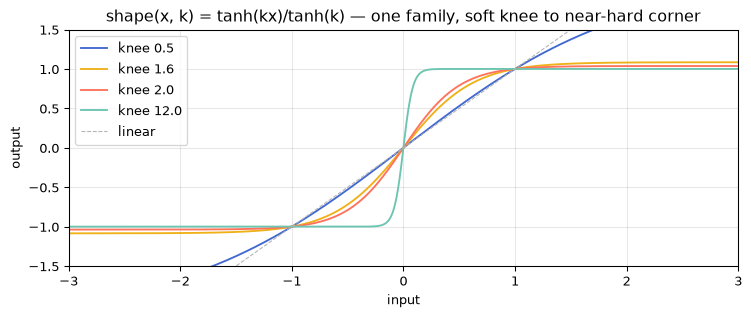

knee   0.5: shape(1) = 1.000000   small-signal slope =  1.082   asymptote = 2.1640
knee   1.6: shape(1) = 1.000000   small-signal slope =  1.736   asymptote = 1.0850
knee   2.0: shape(1) = 1.000000   small-signal slope =  2.075   asymptote = 1.0373
knee  12.0: shape(1) = 1.000000   small-signal slope = 12.000   asymptote = 1.0000


In [2]:
x = np.linspace(-3, 3, 1201)
fig, ax = plt.subplots()
for i, k in enumerate([0.5, 1.6, 2.0, 12.0]):
    y = np.tanh(k * x) / np.tanh(k)
    ax.plot(x, y, color=C[i], lw=1.4, label=f"knee {k}")
ax.plot(x, x, color="0.7", lw=0.8, ls="--", label="linear")
ax.set_xlim(-3, 3); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("input"); ax.set_ylabel("output")
ax.set_title("shape(x, k) = tanh(kx)/tanh(k) — one family, soft knee to near-hard corner")
ax.legend()
plt.show()

for k in [0.5, 1.6, 2.0, 12.0]:
    y = np.tanh(k * x) / np.tanh(k)
    print(f"knee {k:5.1f}: shape(1) = {np.tanh(k)/np.tanh(k):.6f}   "
          f"small-signal slope = {k/np.tanh(k):6.3f}   asymptote = {1/np.tanh(k):.4f}")

## 2 · Gain staging — where the first implementation was wrong

Look at the slope column above. The tanh family's small-signal gain is `k/tanh(k)`, which is
**greater than one and grows with the knee** — about 2 at the stock second-stage knee, and 3
at the knee the first draft used.

That is easy to miss in a single stage and fatal in a cascade. The first cut of this kernel put
a ×2.2 fixed gain in front of a knee-3 curve, so the second stage saw an effective ×6.6 and was
*already fully clipped with the gain knob at zero* — the knob did nothing over most of its
travel. It sounded like a distortion the whole way, which is exactly why listening did not
catch it and a measurement did.

Below: the harmonic-to-fundamental ratio across the knob, after retuning.

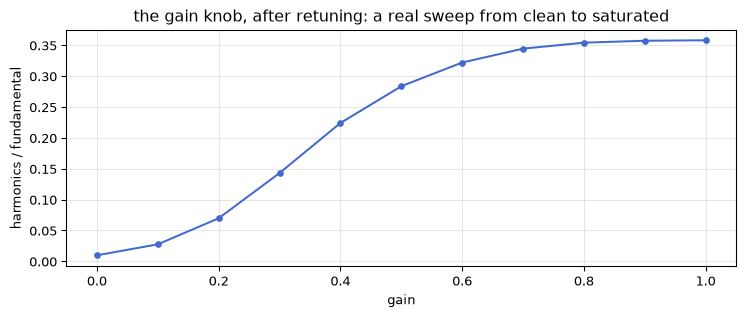

gain 0.0 -> 0.010   (edge of breakup)
gain 0.5 -> 0.284
gain 1.0 -> 0.358   (37x the harmonic content of gain 0)


In [3]:
def harmonic_ratio(gain, f0=220.0):
    y = pedal(gain=gain).process(tone_in(f0))
    f, m = spectrum(y)
    fund = at(f0, f, m)
    harm = np.sqrt(sum(at(f0 * k, f, m) ** 2 for k in range(2, 9)))
    return harm / fund

gains = np.linspace(0, 1, 11)
ratios = [harmonic_ratio(g) for g in gains]

fig, ax = plt.subplots()
ax.plot(gains, ratios, color=C[0], marker="o", ms=4)
ax.set_xlabel("gain"); ax.set_ylabel("harmonics / fundamental")
ax.set_title("the gain knob, after retuning: a real sweep from clean to saturated")
plt.show()

print(f"gain 0.0 -> {ratios[0]:.3f}   (edge of breakup)")
print(f"gain 0.5 -> {ratios[5]:.3f}")
print(f"gain 1.0 -> {ratios[-1]:.3f}   ({ratios[-1] / ratios[0]:.0f}x the harmonic content of gain 0)")

## 3 · The even harmonics

A symmetric static curve is an odd function, so it can only produce odd harmonics. DAFx-07
points out that a real op-amp stage clips *asymmetrically*, which is where a pedal's even
harmonics come from — and that is the whole reason `asymmetry` exists here.

The bias is applied inside the curve and corrected at the stage output, so an asymmetric pedal
is still *exactly* silent on silence: no DC pedestal.

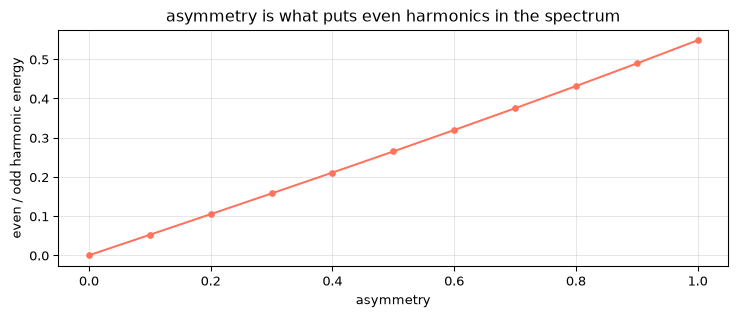

symmetric  (0.0): even/odd = 0.00000  <- odd-only, to the noise floor
asymmetric (1.0): even/odd = 0.54841
and silence is still exactly silent: True


In [4]:
def even_odd(asym, f0=220.0):
    y = pedal(gain=0.8, asymmetry=asym).process(tone_in(f0))
    f, m = spectrum(y)
    even = np.sqrt(sum(at(f0 * k, f, m) ** 2 for k in (2, 4, 6, 8)))
    odd = np.sqrt(sum(at(f0 * k, f, m) ** 2 for k in (3, 5, 7)))
    return even / odd

asyms = np.linspace(0, 1, 11)
ratios = [even_odd(a) for a in asyms]

fig, ax = plt.subplots()
ax.plot(asyms, ratios, color=C[2], marker="o", ms=4)
ax.set_xlabel("asymmetry"); ax.set_ylabel("even / odd harmonic energy")
ax.set_title("asymmetry is what puts even harmonics in the spectrum")
plt.show()

print(f"symmetric  (0.0): even/odd = {ratios[0]:.5f}  <- odd-only, to the noise floor")
print(f"asymmetric (1.0): even/odd = {ratios[-1]:.5f}")
q = tap.Fuzz(sr, smooth_ms=0, gain=1.0, asymmetry=1.0)
print(f"and silence is still exactly silent: {bool(np.all(q.process(np.zeros(4096)) == 0.0))}")

## 4 · The tone stack

Three linear filters entirely outside the nonlinearity — a low shelf, a high shelf, and a mid
scoop whose depth is `contrast`. On this class of pedal the voicing section is most of the
identity, which is why it is a first-class part of the object rather than an afterthought.

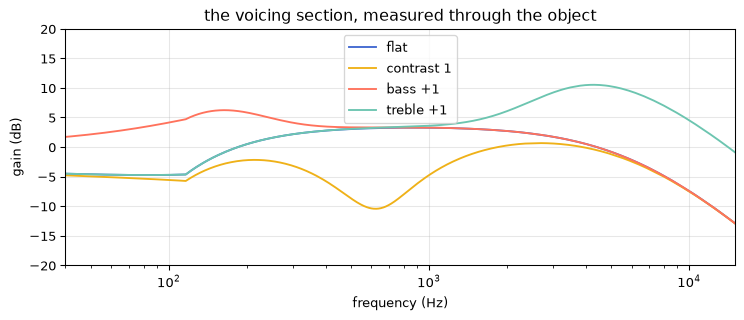

In [5]:
def response(**tone):
    # Measure the voicing at a gain low enough that the curve is near-linear, so what the plot
    # shows is the tone stack rather than the distortion's own spectrum.
    rng = np.random.default_rng(3)
    x = 0.02 * rng.standard_normal(int(2.0 * sr))
    y = pedal(gain=0.0, **tone).process(x)
    f, m = spectrum(y, skip=0.25)
    fr, mr = spectrum(x, skip=0.25)
    keep = (f > 30) & (f < 16000)
    # smooth in log-frequency for a readable curve
    db = 20 * np.log10(np.maximum(m[keep], 1e-12) / np.maximum(mr[keep], 1e-12))
    n = 257
    return f[keep], np.convolve(db, np.ones(n) / n, mode="same")

fig, ax = plt.subplots()
for i, (label, kw) in enumerate([("flat", {}),
                                 ("contrast 1", dict(contrast=1.0)),
                                 ("bass +1", dict(bass=1.0)),
                                 ("treble +1", dict(treble=1.0))]):
    f, db = response(**kw)
    ax.semilogx(f, db, color=C[i], lw=1.4, label=label)
ax.set_xlim(40, 15000); ax.set_ylim(-20, 20)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("gain (dB)")
ax.set_title("the voicing section, measured through the object")
ax.legend()
plt.show()

## 5 · Aliasing — and a house pattern that did not survive contact

A static curve generates harmonics without limit, so anything above Nyquist folds back. The
clipper pair therefore runs oversampled, with an anti-image filter on the way up and a matching
anti-alias filter before decimation.

The house pattern (`tap.ladder~`, `overdrive.h`) uses a **4th-order** Butterworth there. Measured
in this kernel it is not steep enough — fold energy at 4× came out *worse* than at 2× (1.7e-2
against 2.8e-3). Eighth order improves 4× by about 6×, and this file uses it.

It does **not** make the sequence monotone, and the plot below is the honest picture: every
factor beats no oversampling by orders of magnitude, and **2× measures best**, which is why 2×
is the default rather than the largest factor. The cause is not established. The obvious
suspect — biquads going ill-conditioned at the low normalized cutoffs a high factor needs
(0.056 at 8×) — was tested and ruled out: the cascade's impulse response decays cleanly to
denormal at every factor. The untested next hypothesis is imaging (zero-stuffing by N leaves
N−1 images for one filter to suppress, and residuals intermodulate in the clipper into exactly
the non-harmonic products this probe measures), which would point at cascaded 2× resampling as
the fix.

Measuring this correctly took two tries, and both mistakes are easy to repeat:

* **The test tone must not divide the sample rate.** At 3 kHz into 48 kHz, every alias folds
  back exactly onto a harmonic of the input and is invisible.
* **Probes must sit far from the fundamental**, or they measure window leakage from it rather
  than aliasing.

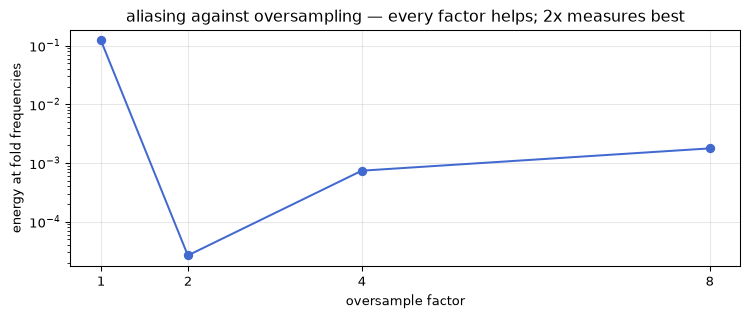

1x: 1.228e-01
2x: 2.659e-05   ( 4618x better than 1x)
4x: 7.399e-04   (  166x better than 1x)
8x: 1.774e-03   (   69x better than 1x)


In [6]:
f0 = 3733.0  # deliberately not a submultiple of the sample rate

def alias_energy(os):
    y = pedal(gain=1.0, edge=1.0, oversample=os).process(tone_in(f0, amp=0.5))
    f, m = spectrum(y)
    total = 0.0
    for k in range(8, 14):
        fold = k * f0
        while fold > sr / 2:
            fold = fold - sr if fold > sr else sr - fold
        if abs(fold - f0) < 1000:      # skip probes that would read leakage, not aliasing
            continue
        total += at(fold, f, m) ** 2
    return np.sqrt(total)

factors = [1, 2, 4, 8]
energies = [alias_energy(o) for o in factors]

fig, ax = plt.subplots()
ax.semilogy(factors, energies, color=C[0], marker="o", ms=6)
ax.set_xticks(factors)
ax.set_xlabel("oversample factor"); ax.set_ylabel("energy at fold frequencies")
ax.set_title("aliasing against oversampling — every factor helps; 2x measures best")
plt.show()

for o, e in zip(factors, energies):
    print(f"{o}x: {e:.3e}" + ("" if o == 1 else f"   ({energies[0] / e:>5.0f}x better than 1x)"))

## Checkpoint

- One tanh family with an adjustable knee, normalized so full scale in is full scale out at
  every knee — monotonic, odd, bounded.
- The gain knob sweeps clean to saturated for real, after a first cut where the cascade's
  compounded small-signal slope had the second stage clipped at zero.
- `asymmetry` is the even-harmonic control, and it costs no DC: silence stays exactly silent.
- The voicing section is three linear filters outside the nonlinearity.
- Oversampling buys orders of magnitude against none, with an 8th-order filter because the
  house 4th-order one measured worse at higher factors — but bigger is not better here, 2×
  measures best, and why that is remains open.

Every number above lives twice: as a cell in this notebook and as a pinned scenario in
`tests/fuzz_test.cpp`.